# 🚴‍♂️ Projet Data Science : Prédiction de la disponibilité des Vélib' à Paris

## 1. Contexte du projet
À Paris, utiliser les vélos en libre-service (Vélib') est un moyen de transport très prisé, mais qui vient avec une frustration bien connue : arriver à une station vide quand on veut partir, ou faire face à une station pleine quand on veut se garer. La disponibilité des vélos dépend de facteurs complexes : l'heure, le jour de la semaine, la météo, et l'inertie de la station.

## 2. Objectif
L'objectif de ce Notebook est de construire un modèle de Machine Learning capable de prédire le **taux de remplissage (`filling_rate`)** d'une station dans le futur proche. 

## 3. Plan d'action (Pipeline)
Pour atteindre cet objectif, nous allons suivre les étapes clés d'un projet Data de bout en bout :

1. **Collecte et Nettoyage des données :** Traitement des valeurs manquantes (imputation) et correction des anomalies de l'API (taux > 100%).
2. **Feature Engineering :** Création de variables intelligentes pour aider le modèle :
   - Encodage cyclique du temps (Trigonométrie pour les heures et les mois).
   - Variables retardées (*Lag Features*) pour capturer l'inertie de la station.
3. **Modélisation :** Entraînement d'algorithmes basés sur les arbres (Random Forest, LightGBM) en respectant la chronologie du temps (séparation Train/Test sans *Data Leakage*).
4. **Évaluation & Sauvegarde :** Validation de la robustesse du modèle sur des données futures et exportation pour le déploiement.

---
*Prêt pour l'analyse ! Importons d'abord nos librairies et nos données.*

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

# Importation des données et Nettoyage

In [39]:
def load_data():
    try:
        conn = sqlite3.connect("velib_data.db")
        df = pd.read_sql("SELECT * FROM availabilities",conn)
        conn.close
        print(f"L'importation des données a été faite avec succées ")
        print(f"Le nombre des lignes chargées est : {df.shape[0]}")
        return df
    except Exception as e:
        print(f"Erreur {e}")
df = load_data()
print(df.info()) # Pour avoir les informations nécessaire sur le type et le nombre des entrées .
print(df.isna().sum()) # Pour avoir plus de détail sur les valuers manquantes
df.head()

L'importation des données a été faite avec succées 
Le nombre des lignes chargées est : 536336
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536336 entries, 0 to 536335
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   stationcode        530325 non-null  object 
 1   name               524225 non-null  object 
 2   filling_rate       536336 non-null  float64
 3   numbikesavailable  536336 non-null  int64  
 4   capacity           524225 non-null  float64
 5   lat                524225 non-null  float64
 6   lon                524225 non-null  float64
 7   event_date         536336 non-null  object 
 8   ingestion_date     536336 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 36.8+ MB
None
stationcode           6011
name                 12111
filling_rate             0
numbikesavailable        0
capacity             12111
lat                  12111
lon                  12111

,stationcode,name,filling_rate,numbikesavailable,capacity,lat,lon,event_date,ingestion_date
0,16107,Benjamin Godard - Victor Hugo,0.171429,6,35.0,48.865983,2.275725,2026-02-05T14:53:20+00:00,2026-02-05 16:34:57
1,14111,Cassini - Denfert-Rochereau,0.080000,2,25.0,48.837526,2.336035,2026-02-05T14:53:18+00:00,2026-02-05 16:34:57
2,40001,Hôpital Mondor,0.464286,13,28.0,48.798922,2.453745,2026-02-05T14:55:59+00:00,2026-02-05 16:34:57
3,32017,Basilique,0.545455,12,22.0,48.936269,2.358867,2026-02-05T14:57:26+00:00,2026-02-05 16:34:57
4,32304,Charcot - Benfleet,0.071429,2,28.0,48.878370,2.440524,2026-02-05T14:54:47+00:00,2026-02-05 16:34:57


On remarque que le type des colonnes **event_date** et **ingestion_date** est **object**, mais nous voulons qu'elles soient de type **datetime**.
De plus, il y a des valeurs manquantes (9410 au total). Cependant, si on regarde bien, on constate que la colonne **stationcode** ne compte que 4507 valeurs manquantes. Nous allons donc essayer de sauver les autres lignes qui contiennent un code de station valide.

In [40]:
df[df['stationcode'].notna() & (df['name'].isna())]

,stationcode,name,filling_rate,numbikesavailable,capacity,lat,lon,event_date,ingestion_date
34661,32304,None,0.0,2,NaN,NaN,NaN,2026-02-05T22:56:58+00:00,2026-02-06 00:30:48
34662,16107,None,0.0,7,NaN,NaN,NaN,2026-02-05T22:53:23+00:00,2026-02-06 00:30:48
34663,11104,None,0.0,10,NaN,NaN,NaN,2026-02-05T22:56:03+00:00,2026-02-06 00:30:48
34664,40001,None,0.0,11,NaN,NaN,NaN,2026-02-05T22:55:42+00:00,2026-02-06 00:30:48
34665,6003,None,0.0,10,NaN,NaN,NaN,2026-02-05T22:53:20+00:00,2026-02-06 00:30:48
...,...,...,...,...,...,...,...,...,...
534823,12127,None,0.0,65,NaN,NaN,NaN,2026-02-23T16:49:23+00:00,2026-02-23 18:15:51
534824,5202,None,0.0,4,NaN,NaN,NaN,2026-02-23T16:48:03+00:00,2026-02-23 18:15:51
534825,9104,None,0.0,19,NaN,NaN,NaN,2026-02-23T16:49:06+00:00,2026-02-23 18:15:51
534826,19018,None,0.0,13,NaN,NaN,NaN,2026-02-23T16:47:10+00:00,2026-02-23 18:15:51


Remarquons que même si les colonnes **name**, **capacity**, **lat** et **lon** sont manquantes, la colonne **numbikesavailable** ne l'est pas, ce qui est un bon indice que l'on peut sauver nos données.

Parfois, les mêmes données sont ingérées plusieurs fois par l'API. Cela crée des doublons (lignes identiques pour la même station à la même heure) qui risquent de fausser l'apprentissage de notre modèle de Machine Learning. Nous allons donc les supprimer en gardant uniquement la dernière valeur enregistrée.

Donc on va créer une fonction pour faire les transformations nécessaires.

In [41]:
def transform_data(dataframe):
    df = dataframe.copy()
    
    # 1. Transformation des Types :
    if "event_date" in df.columns:
        df["event_date"] = pd.to_datetime(df["event_date"])
    if "ingestion_date" in df.columns:
        df["ingestion_date"] = pd.to_datetime(df["ingestion_date"])
        
    # 2. On commence par sauver les valeurs manquantes : 
    df = df.sort_values(by=['stationcode', 'event_date'])
    colonnes_a_sauver = ['name', 'capacity', 'lat', 'lon']
    
    df[colonnes_a_sauver] = df.groupby("stationcode")[colonnes_a_sauver].ffill()
    df[colonnes_a_sauver] = df.groupby("stationcode")[colonnes_a_sauver].bfill()
    
    # "est" au singulier, et "sauvées" au lieu de "fixées"
    print(f"Le nombre de lignes sauvées est : {9410 - df['name'].isna().sum()}")
    
    # 3. Nettoyage final :
    df = df.drop_duplicates(subset=["stationcode", "event_date"], keep='last') # Pour supprimer les doublons
    df = df.dropna() # Pour supprimer les VALEURS MANQUANTES qu'on ne peut pas sauver (et non les doublons)
    
    print(f"La nouvelle taille de notre jeu de données est : {df.shape[0]}")
    return df

# Application de la fonction
df_new = transform_data(df)

# Vérifications
print(df_new.info())
print(df_new.isna().sum())

Le nombre de lignes sauvées est : 3399
La nouvelle taille de notre jeu de données est : 238498
<class 'pandas.core.frame.DataFrame'>
Index: 238498 entries, 2596 to 535068
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   stationcode        238498 non-null  object             
 1   name               238498 non-null  object             
 2   filling_rate       238498 non-null  float64            
 3   numbikesavailable  238498 non-null  int64              
 4   capacity           238498 non-null  float64            
 5   lat                238498 non-null  float64            
 6   lon                238498 non-null  float64            
 7   event_date         238498 non-null  datetime64[ns, UTC]
 8   ingestion_date     238498 non-null  datetime64[ns]     
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 18.2+ MB
None
stationcode    

Maintenant, nous devons créer une colonne **filling_rate** (taux de remplissage). En effet, les colonnes brutes **numbikesavailable** et **capacity** ne donnent pas l'information réelle. Sans ce ratio, lors de l'étape de Machine Learning, une station de 30 places contenant 5 vélos sera traitée de la même manière qu'une station de 10 places contenant aussi 5 vélos. Pour permettre au modèle de faire la distinction, l'ajout de la colonne **filling_rate** est indispensable.

stationcode          0
name                 0
filling_rate         0
numbikesavailable    0
capacity             0
lat                  0
lon                  0
event_date           0
ingestion_date       0
dtype: int64
Index(['stationcode', 'name', 'filling_rate', 'numbikesavailable', 'capacity',
       'lat', 'lon', 'event_date', 'ingestion_date'],
      dtype='object')
--------------------------------------------------


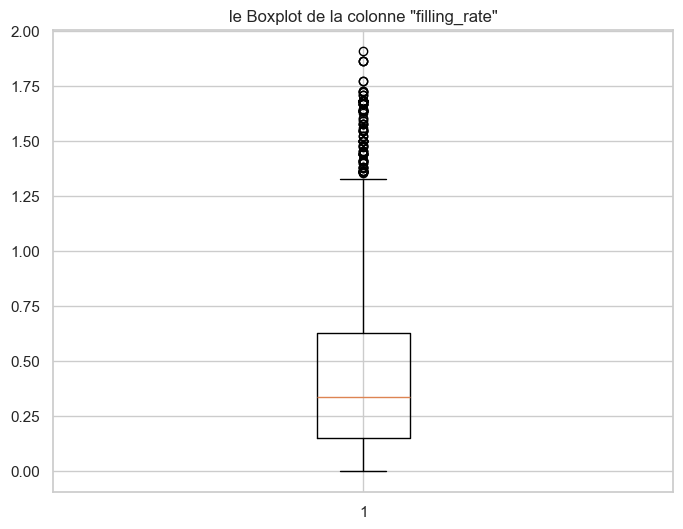

In [42]:
df_new["filling_rate"] = np.where(df_new['capacity']==0,0
                                  ,
                                  df_new['numbikesavailable'] / df_new['capacity']
                                  ) # Pour éviter une division par 0 (les stations avec une capacité de 0 peuvent être en travaux, fermées ou hors service).
print(df_new.isna().sum())
print(df_new.columns)
print("-"*50)
plt.figure(figsize=(8,6))
plt.boxplot(df_new['filling_rate'])
plt.title('le Boxplot de la colonne "filling_rate"')
plt.show()

On remarque la présence d'anomalies, c'est-à-dire des valeurs qui dépassent 1 pour le **filling_rate**. C'est un phénomène tout à fait normal, car le service Vélib' permet de stationner des vélos même si la station est déjà pleine. Nous allons donc procéder aux transformations nécessaires pour corriger cela :

Taux minimum : 0.0
Taux maximum : 1.0
Taux moyen   : 0.40
------------------------------------------------------------


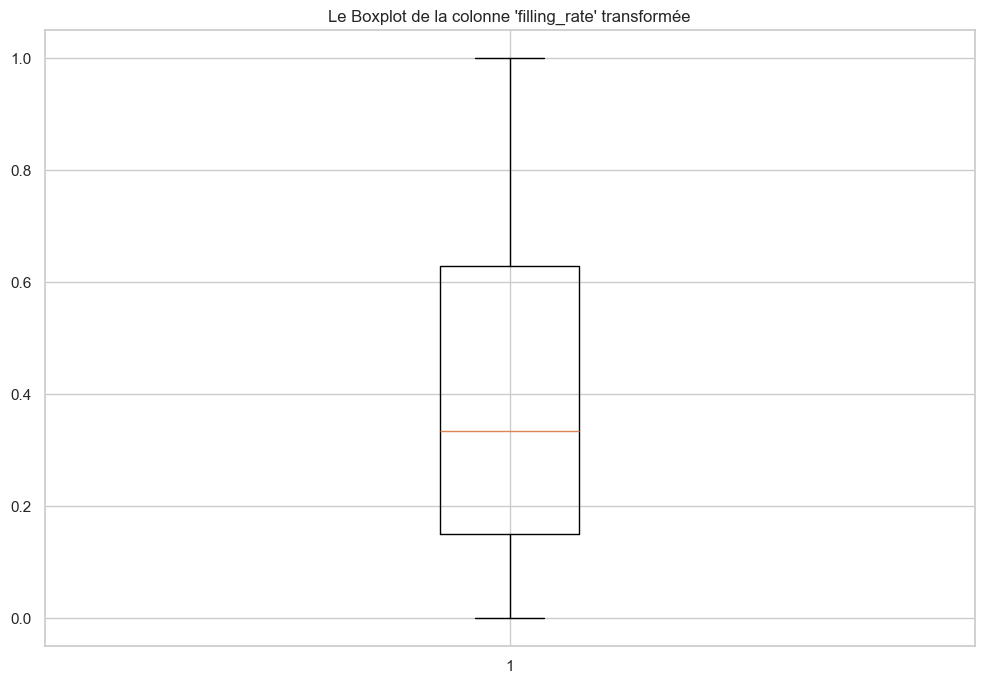

In [43]:
# La fonction clip() force les valeurs à rester entre 0.0 et 1.0
df_new['filling_rate'] = df_new['filling_rate'].clip(upper=1.0)
print(f"Taux minimum : {df_new['filling_rate'].min()}")
print(f"Taux maximum : {df_new['filling_rate'].max()}")
print(f"Taux moyen   : {df_new['filling_rate'].mean():.2f}")
print("-"*60)
# En faisant le Boxplot :
plt.figure(figsize=(12,8))
plt.boxplot(df_new['filling_rate'])
plt.title("Le Boxplot de la colonne 'filling_rate' transformée")
plt.show()

### Maintenant, nous devons passer à la création des features temporelles

1. **L'extraction classique** : Sortir l'heure, le jour et le mois de la colonne event_date.
2. **L'encodage cyclique** : Si on donne juste l'heure (0 à 23) à un modèle, il va penser que 23h et 0h sont mathématiquement très éloignés (23 - 0 = 23). Or, dans la vraie vie, minuit suit 23h ! On va donc utiliser le sinus et le cosinus pour modéliser cette boucle temporelle en utilisant la formule $2\pi \times \frac{\text{heure}}{24}$.

In [44]:
# 1. Extraction Classique : 
df_new['hour'] = df_new['event_date'].dt.hour
df_new['day'] = df_new['event_date'].dt.day
df_new['month'] = df_new['event_date'].dt.month
df_new['day_of_week'] = df_new['event_date'].dt.day_of_week # Lundi = 0 et dimanche = 6
df_new['is_weekend'] = np.where(df_new['day_of_week']>=5,1,0)
# 2. Encodage Cyclique : 
df_new['hour_cos'] = np.cos(2*np.pi*df_new['hour']/24)
df_new['hour_sin'] = np.sin(2*np.pi*df_new['hour']/24)
df_new['day_sin'] = np.sin(2 * np.pi * df_new['day_of_week'] / 7)
df_new['day_cos'] = np.cos(2 * np.pi * df_new['day_of_week'] / 7)
# 3. Affichage des variables :
colonnes_temporelles = ['hour','day','month','day_of_week','is_weekend','hour_cos','hour_sin']
df_new[colonnes_temporelles].head()

,hour,day,month,day_of_week,is_weekend,hour_cos,hour_sin
2596,13,5,2,3,0,-0.965926,-0.258819
4184,14,5,2,3,0,-0.866025,-0.500000
11742,15,5,2,3,0,-0.707107,-0.707107
16339,16,5,2,3,0,-0.500000,-0.866025
14789,17,5,2,3,0,-0.258819,-0.965926


### Création des "Lag Features" (La mémoire du modèle)

Pour qu'un modèle de Machine Learning soit performant sur des séries temporelles (Time Series), il ne doit pas être "aveugle" au passé. Actuellement, notre algorithme lit chaque ligne de manière isolée. 

Nous allons donc créer une **Lag Feature** (exactement comme la fonction `LAG()` en SQL). Le principe est de récupérer le taux de remplissage d'une station et de le décaler d'une heure (`H-1`). 
* **Pourquoi ?** Parce que le meilleur indicateur pour prédire la disponibilité des vélos à 15h, c'est de connaître l'état de la station à 14h. Cela donne au modèle une notion d'inertie et lui permet de comprendre si la station est en train de se vider ou de se remplir.

In [45]:
df_new = df_new.sort_values(by=['stationcode','event_date'])
df_new['filling_rate_H_minus_1'] = df_new.groupby('stationcode')['filling_rate'].shift(1)
print(f"Valeurs manquantes créées par le décalage : {df_new['filling_rate_H_minus_1'].isna().sum()}")
df_new = df_new.dropna(subset=['filling_rate_H_minus_1'])
print("Colonne 'filling_rate_H_minus_1' créée avec succès !")

Valeurs manquantes créées par le décalage : 1508
Colonne 'filling_rate_H_minus_1' créée avec succès !


# EDA(Exploratory Data Analysis)

## Matrice de Corrélation

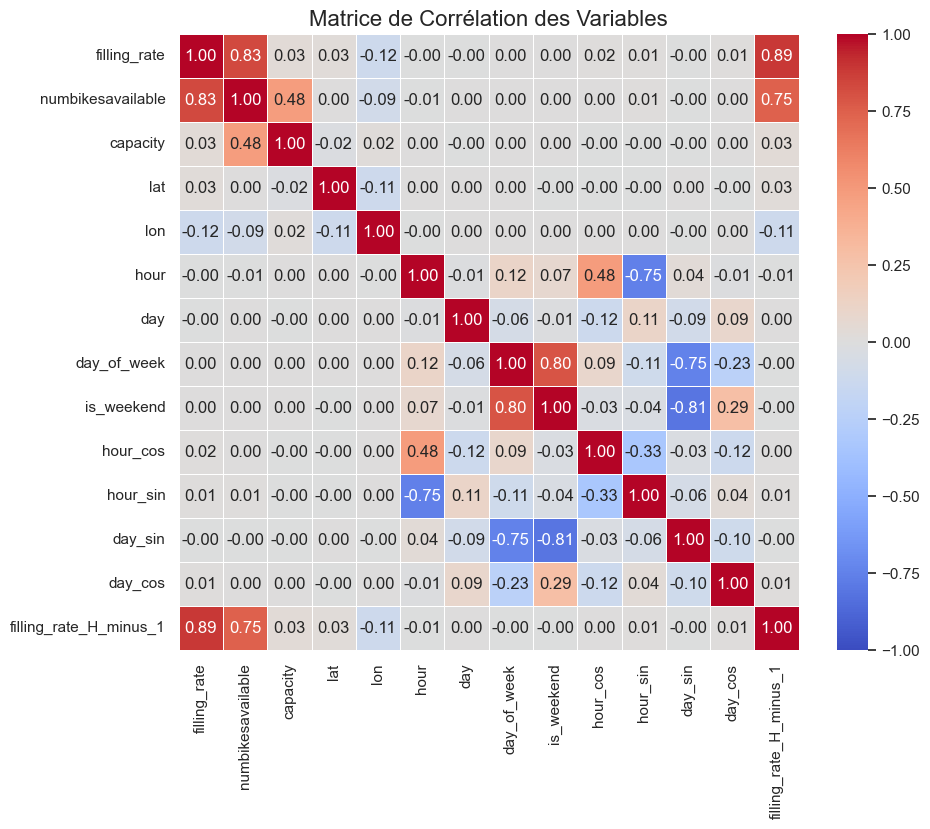

In [74]:
matrice_correlation = df_new.drop(columns=['month']).corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.title('Matrice de Corrélation des Variables', fontsize=16)
sns.heatmap(matrice_correlation,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,linewidths=0.5)
plt.show()

D'après notre matrice de corrélation, on peut constater que notre variable à prédire, le **filling_rate**, a une très forte corrélation avec les colonnes **numbikesavailable** (0.83)(qui est normal on l'a utilsé pour calculer le filling rate) et **filling_rate_H_minus_1** (0.88). Cela prouve que notre choix de créer cette variable de lag était excellent !

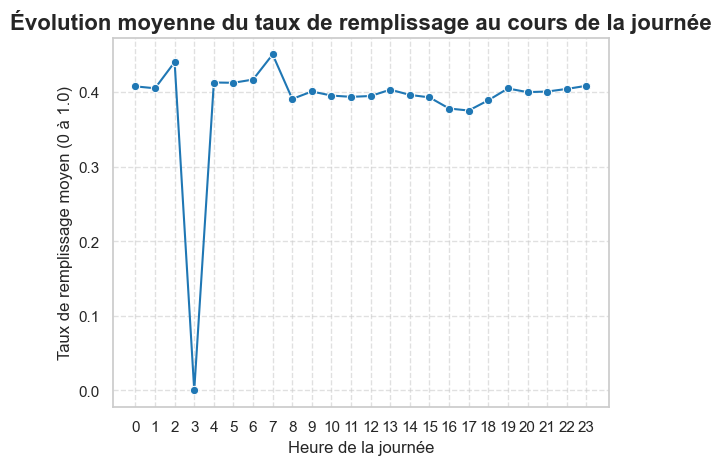

In [75]:
sns.lineplot(df_new,x='hour',y='filling_rate', 
    marker='o',
    color='#1f77b4', 
    errorbar=None)
plt.title('Évolution moyenne du taux de remplissage au cours de la journée', fontsize=16, fontweight='bold')
plt.xlabel('Heure de la journée', fontsize=12)
plt.ylabel('Taux de remplissage moyen (0 à 1.0)', fontsize=12)

plt.xticks(range(0, 24))

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

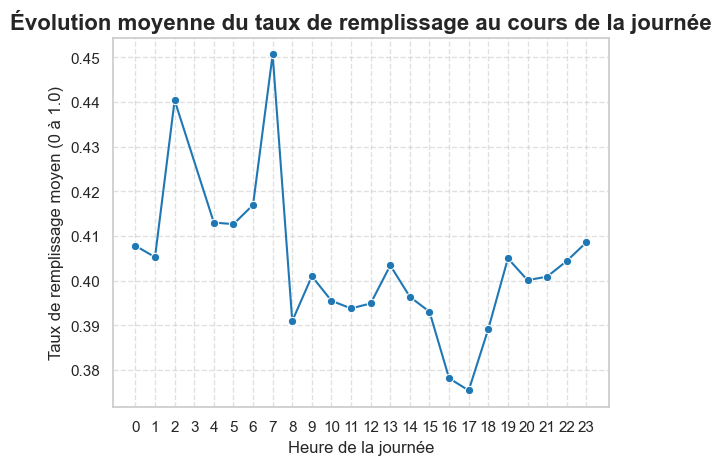

In [76]:
df_new = df_new[df_new['hour'] != 3]
sns.lineplot(df_new,x='hour',y='filling_rate', 
    marker='o',
    color='#1f77b4', 
    errorbar=None)
plt.title('Évolution moyenne du taux de remplissage au cours de la journée', fontsize=16, fontweight='bold')
plt.xlabel('Heure de la journée', fontsize=12)
plt.ylabel('Taux de remplissage moyen (0 à 1.0)', fontsize=12)

plt.xticks(range(0, 24))

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Analyse et correction de l'anomalie de 3h du matin

Lors de la visualisation de l'évolution temporelle du taux de remplissage, nous avons repéré une anomalie flagrante : une chute brutale du taux à **0.0** à 3h du matin. 

Il s'agit d'un **artefact de collecte**. La récupération des données s'est interrompue à cette heure-là (arrêt de la machine exécutant le script d'ingestion), ce qui a généré des valeurs nulles par défaut. 

**Action :** Si nous conservons ces lignes, notre modèle de Machine Learning va apprendre une fausse règle mathématique ("à 3h, tous les vélos disparaissent"). Pour garantir la robustesse de notre modèle, nous supprimons purement et simplement les enregistrements liés à cette heure "fantôme".

On voit clairement les mouvements des Parisiens :

1. **Le pic de 7h du matin** : Le remplissage global monte d'un coup. Les stations se remplissent probablement près des gares ou des zones de bureaux.

2. **Le creux de 17h** : C'est la fin de la journée de travail, le taux de remplissage global chute, beaucoup de vélos sont en cours d'utilisation dans les rues ou ramenés vers les zones résidentielles.

## ACP 
**Le but de l'ACP** : Regrouper les variables qui racontent la même chose pour simplifier les calculs de l'Intelligence Artificielle.

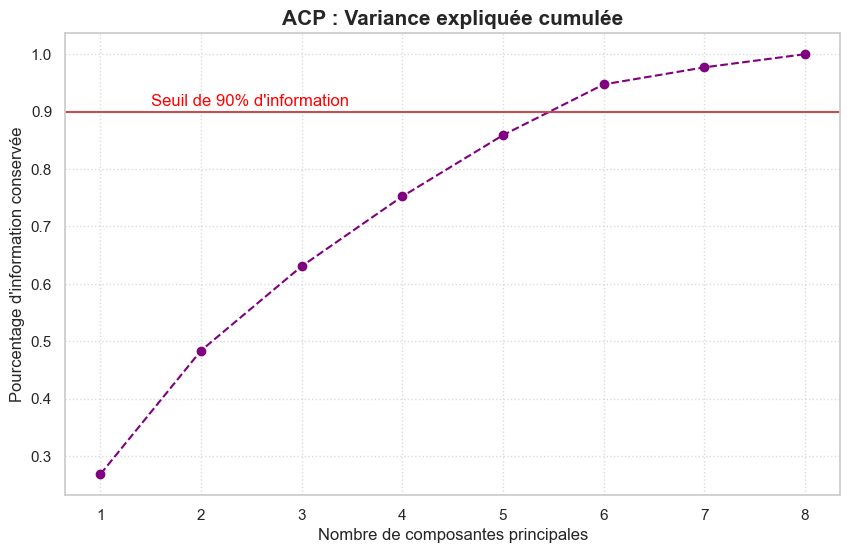

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
features = ['lat','lon','hour','day_of_week','is_weekend','hour_sin','hour_cos','filling_rate_H_minus_1']
X = df_new[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(features) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='purple')

plt.title('ACP : Variance expliquée cumulée', fontsize=15, fontweight='bold')
plt.xlabel('Nombre de composantes principales', fontsize=12)
plt.ylabel('Pourcentage d\'information conservée', fontsize=12)

# On ajoute une ligne rouge à 90% d'information
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1.5, 0.91, 'Seuil de 90% d\'information', color='red')

plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

L'ACP montre qu'il faut conserver 6 composantes principales pour expliquer plus de 90% de la variance. La réduction de dimensionnalité (de 8 variables initiales à 6 composantes) étant très faible, nous décidons de ne pas appliquer l'ACP pour la suite du projet. Conserver nos 8 variables d'origine nous permettra de garder une parfaite interprétabilité lors de l'entraînement de notre modèle de Machine Learning.

# Machine Learning

## Sans La Variable Filling_rate_H_minus_1

Dans cette Partie on va travailler sans notre nouvelle variable qui va construire un modèle dirégé vers l'utilisateur qui veut savoir dans le futur le taux de remplissage d'une station précise pour faire sa décision , on va voir les résultats de ce modèle et on fait la comparaision à la fin .

### Test/Train Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:

df_new = df_new.sort_values(by='event_date')
features = ['lat', 'lon', 'capacity', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend']
target = 'filling_rate'
X = df_new[features].values
y = df_new[target].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
print(" Séparation réussie avec train_test_split !")
print(f" Lignes pour l'entraînement (Train) : {X_train.shape[0]}")
print(f" Lignes pour le test (Test)         : {X_test.shape[0]}")

 Séparation réussie avec train_test_split !
 Lignes pour l'entraînement (Train) : 163580
 Lignes pour le test (Test)         : 70106


### Régression Linéaire 

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE,r2_score

In [14]:
lr = LinearRegression()
lr.fit(X_train,y_train)
predict_lr = lr.predict(X_test)
score_lr = r2_score(y_test,predict_lr)
mae_lr = MAE(y_test,predict_lr)
print("L'erreur moyenne MAE du modèle est : {:.3f}".format(mae_lr))
print("La précision du module est : {:.3f}".format(score_lr))

L'erreur moyenne MAE du modèle est : 0.244
La précision du module est : 0.016


### Random Forest Regressor

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
rf = RandomForestRegressor(n_estimators=200,n_jobs=-1,random_state=42)
rf.fit(X_train,y_train)
predict_rf = rf.predict(X_test)
score_rf = r2_score(y_test,predict_rf)
mae_rf = MAE(y_test,predict_rf)
print("L'erreur moyenne MAE du modèle est : {:.3f}".format(mae_rf))
print('La précision du modèle est : {:.4f}'.format(score_rf))

L'erreur moyenne MAE du modèle est : 0.132
La précision du modèle est : 0.6063


#### HyperParameter Tuning pour RandomForest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# 1. On définit la grille des réglages à tester
parametres_a_tester = {
    'n_estimators': [100, 200, 300],       # Nombre d'arbres
    'max_depth': [None, 10, 20, 30, 40],        # Profondeur max de l'arbre
    'min_samples_split': [2, 5, 10],            # Nombre min de données pour créer une branche
    'min_samples_leaf': [1, 2, 4],              # Nombre min de données à la fin d'une branche
    'max_features': ['sqrt', 'log2', None]      # Nombre de variables regardées à chaque division
}

# 2. On prépare le modèle de base
rf_base = RandomForestRegressor(random_state=42)

# 3. On lance la recherche (RandomizedSearch)
print(" Recherche des meilleurs paramètres en cours...")
recherche = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=parametres_a_tester, 
    n_iter=20,          
    cv=3,               
    verbose=2,          
    random_state=42, 
    n_jobs=-1          
)

# On entraîne sur la grille
recherche.fit(X_train, y_train)

# 4. Affichage des résultats magiques
print("\n" + "="*50)
print(" MEILLEURS PARAMÈTRES TROUVÉS :")
print(recherche.best_params_)
print("="*50 + "\n")

# 5. On teste direct ce nouveau modèle optimisé
meilleur_modele_rf = recherche.best_estimator_
predict_best = meilleur_modele_rf.predict(X_test)
score_best = r2_score(y_test, predict_best)

print(' La précision du NOUVEAU modèle optimisé est : {:.4f}'.format(score_best))

* Remarquons qu on a pu gagné 6 points de plus sur le Score $R^2$ en cherchant les meilleurs parametres .
* Maintenant On va Créer une Pipeline pour determiner les meilleurs modèles en utilisant plusieurs Modèles connues (**XGBoost**,**CatBoost**,**LightGbm**)

### PipeLines

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error as MAE,mean_squared_error as MSE

In [31]:
pipelines = {
    "Random Forest (optimisé)":Pipeline([
        ('Scaler',StandardScaler()),
        ('rf',RandomForestRegressor(
            n_estimators=300, 
            min_samples_split=5, 
            min_samples_leaf=4, 
            max_features=None, 
            max_depth=None,
            random_state=42, 
            n_jobs=-1
        ))]),
        "XGBoost":Pipeline([('Scaler',StandardScaler()),('xgb',xgb.XGBRFRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
        "LightGBM":Pipeline([('Scaler',StandardScaler()),('lgbm',lgb.LGBMRegressor(n_estimators=300,random_state=42, n_jobs=-1))]),
        "KNN":Pipeline([('Scaler',StandardScaler()),("knn",KNeighborsRegressor(n_neighbors=5,n_jobs=-1))])
}
results = {}
for model_name, pipeline in pipelines.items():
    print(f"Entrainement de {model_name} en cours...")
    pipeline.fit(X_train,y_train)
    predictions = pipeline.predict(X_test)
    score = r2_score(y_test,predictions)
    mae = MAE(y_test,predictions)
    RMSE = MSE(y_test,predictions)**0.5
    results[model_name] = {'R2':score,'MAE':mae,'RMSE':RMSE}
print("\n" + "="*55)
print(" CLASSEMENT FINAL DU PIPELINE")
print("="*55)
results_sorted = sorted(results.items(),key =lambda x: x[1]['R2'],reverse = True)
for nom, scores in results_sorted:
    print(f"{nom.ljust(30)} | R2 : {scores['R2']:.4f} | MAE : {scores['MAE']:.4f} | RMSE : {scores['RMSE']:.4f}")
print("="*55)

Entrainement de Random Forest (optimisé) en cours...
Entrainement de XGBoost en cours...
Entrainement de LightGBM en cours...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 163580, number of used features: 8
[LightGBM] [Info] Start training from score 0.399001


c:\Users\maysttro\Desktop\Data Science\Projects\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Entrainement de KNN en cours...

 CLASSEMENT FINAL DU PIPELINE
Random Forest (optimisé)       | R2 : 0.6764 | MAE : 0.1228 | RMSE : 0.1628
LightGBM                       | R2 : 0.5864 | MAE : 0.1459 | RMSE : 0.1841
KNN                            | R2 : 0.3885 | MAE : 0.1744 | RMSE : 0.2238
XGBoost                        | R2 : 0.3307 | MAE : 0.1935 | RMSE : 0.2342


On remarque que Random Forest(optimisé) est le gagnat, en ravanche on peut remarquer aussi que **LightGBM** a un score mieux que les deux autres modèles **KNN** et **XGBoost** on va essayer de faire **HyperParameter** Tuning pour **LightGBM**

### LightGBM(Optimisaté)

In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:

# 1. On recrée le pipeline de base
pipeline_lgbm = Pipeline([
    ("scaler", StandardScaler()),
    ("lgbm", lgb.LGBMRegressor(random_state=42, n_jobs=-1))
])

# 2. La grille secrète des meilleurs paramètres de LightGBM
parametres_lgbm = {
    'lgbm__n_estimators': [200, 300, 500, 800],        # Nombre d'arbres
    'lgbm__learning_rate': [0.01, 0.05, 0.1, 0.2],     # Vitesse d'apprentissage
    'lgbm__num_leaves': [31, 50, 80, 120],             # Le paramètre LE PLUS IMPORTANT pour LightGBM (complexité)
    'lgbm__max_depth': [-1, 10, 20, 30],               # Profondeur (-1 = pas de limite)
    'lgbm__subsample': [0.7, 0.8, 0.9, 1.0],           # % de données par arbre
    'lgbm__colsample_bytree': [0.7, 0.8, 0.9, 1.0]     # % de colonnes par arbre
}

# 3. On configure la Cross-Validation (5 plis)
print(" Tuning de LightGBM avec Cross-Validation en cours... (ça va chauffer !)")
recherche_cv_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=parametres_lgbm,
    n_iter=30,          # On teste 30 combinaisons au hasard parmi la grille
    cv=5,               # Cross-Validation à 5 plis (très robuste)
    scoring='r2',       # On cherche à maximiser le R2
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. On lance la machine de guerre
recherche_cv_lgbm.fit(X_train, y_train)

# 5. Affichage du grand vainqueur
print("\n" + "="*50)
print(" MEILLEURS PARAMÈTRES TROUVÉS POUR LIGHTGBM :")
print(recherche_cv_lgbm.best_params_)

# 6. Le test de vérité sur X_test
meilleur_modele_lgbm = recherche_cv_lgbm.best_estimator_
predict_cv_lgbm = meilleur_modele_lgbm.predict(X_test)
score_cv_lgbm = r2_score(y_test, predict_cv_lgbm)

print(f"\n LE SCORE ULTIME DE LIGHTGBM : {score_cv_lgbm:.4f}")
print("="*50 + "\n")

 Tuning de LightGBM avec Cross-Validation en cours... (ça va chauffer !)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 163580, number of used features: 8
[LightGBM] [Info] Start training from score 0.399001

 MEILLEURS PARAMÈTRES TROUVÉS POUR LIGHTGBM :
{'lgbm__subsample': 0.7, 'lgbm__num_leaves': 120, 'lgbm__n_estimators': 800, 'lgbm__max_depth': 20, 'lgbm__learning_rate': 0.1, 'lgbm__colsample_bytree': 1.0}


c:\Users\maysttro\Desktop\Data Science\Projects\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 LE SCORE ULTIME DE LIGHTGBM : 0.6799



{'lgbm__subsample': 0.7, 'lgbm__num_leaves': 120, 'lgbm__n_estimators': 800, 'lgbm__max_depth': 20, 'lgbm__learning_rate': 0.1, 'lgbm__colsample_bytree': 1.0}


### Comparaison des modèles : 

C:\Users\maysttro\AppData\Local\Temp\ipykernel_14856\106420041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graphique = sns.barplot(


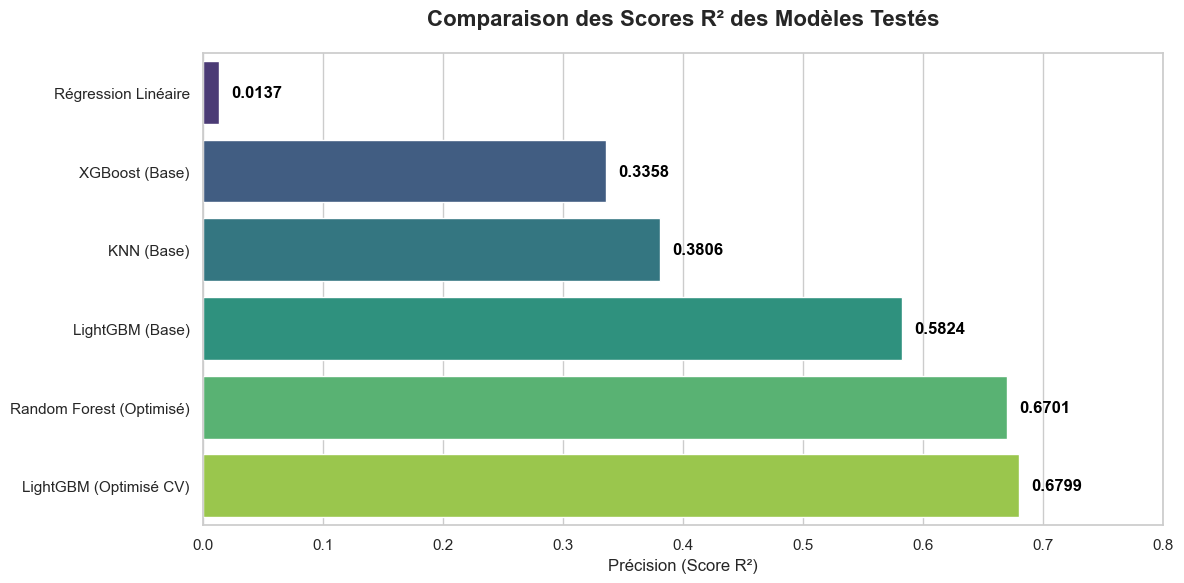

In [ ]:
donnees_scores = {
    'Modèle': [
        'Régression Linéaire', 
        'XGBoost (Base)', 
        'KNN (Base)', 
        'LightGBM (Base)', 
        'Random Forest (Optimisé)', 
        'LightGBM (Optimisé CV)'
    ],
    'Score R2': [
        score_lr, 
        0.3358, 
        0.3806, 
        0.5824, 
        0.6701, 
        0.6799
    ]
}
df_scores = pd.DataFrame(donnees_scores)

# On trie du plus petit au plus grand pour que le graphique soit propre
df_scores = df_scores.sort_values(by='Score R2', ascending=True)

# 2. Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6)) # On fait une belle image large

# 3. Création du graphique en barres horizontales
graphique = sns.barplot(
    x='Score R2', 
    y='Modèle', 
    data=df_scores, 
    palette="viridis" # Une jolie palette de couleurs de pro
)

# 4. Ajout des chiffres exacts au bout de chaque barre
for index, valeur in enumerate(df_scores['Score R2']):
    graphique.text(
        valeur + 0.01, # Position X (juste après la barre)
        index,         # Position Y
        f"{valeur:.4f}", # Le texte (le score avec 4 décimales)
        color='black', 
        va="center", 
        fontweight='bold'
    )

# 5. Les finitions (Titres et axes)
plt.title("Comparaison des Scores R² des Modèles Testés", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Précision (Score R²)", fontsize=12)
plt.ylabel("") # Pas besoin d'écrire "Modèle", c'est évident
plt.xlim(0, 0.8) # On bloque l'axe X à 0.8 pour laisser de la place au texte

plt.tight_layout()
plt.show()

### modèle final :

In [70]:
import joblib
joblib.dump(meilleur_modele_lgbm, 'velib_model_lgbm_cv_final.pkl')
print(" Modèle sauvegardé sous le nom 'velib_model_lgbm_cv_final.pkl'")

 Modèle sauvegardé sous le nom 'velib_model_lgbm_cv_final.pkl'


## Avec La Variable Filling_rate_H_minus_1 

### Séparation Train / Test

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
df_new = df_new.sort_values(by='event_date')
colonnes_a_supprimer = ['filling_rate','name','stationcode','numbikesavailable','capacity','event_date','ingestion_date']
X = df_new.drop(columns=colonnes_a_supprimer,errors='ignore')
y = df_new['filling_rate']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,shuffle=False)
print(" Séparation réussie avec train_test_split !")
print(f" Lignes pour l'entraînement (Train) : {X_train.shape[0]}")
print(f" Lignes pour le test (Test)         : {X_test.shape[0]}")
print(f"Variables conservées : {list(X_train.columns)}")

 Séparation réussie avec train_test_split !
 Lignes pour l'entraînement (Train) : 165893
 Lignes pour le test (Test)         : 71097
Variables conservées : ['lat', 'lon', 'hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_cos', 'hour_sin', 'day_sin', 'day_cos', 'filling_rate_H_minus_1']


### Régression linéaire :


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [50]:
# 1. Initialisation du modèle
modele_lr = LinearRegression()
# 2. Entraînement
modele_lr.fit(X_train,y_train)
# 3. Prédiction
prediction_lr = modele_lr.predict(X_test)
# 4. Évaluation des performances
mae_lr = mean_absolute_error(y_test, prediction_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, prediction_lr))
r2_lr = r2_score(y_test, prediction_lr)
print(" Résultats de la Régression Linéaire :")
print(f"MAE  (Erreur Moyenne) : {mae_lr:.4f}")
print(f"RMSE (Erreur Max)     : {rmse_lr:.4f}")
print(f"R²   (Score global)   : {r2_lr:.4f}")

 Résultats de la Régression Linéaire :
MAE  (Erreur Moyenne) : 0.0890
RMSE (Erreur Max)     : 0.1372
R²   (Score global)   : 0.7793


* **MAE** : 0.0890 signifie que le modèle se trompe en moyenne de **9%** . Si une station a une capacité de 20 vélos, le modèle va en prédire 10 alors qu'il y en a peut-être 8 ou 12. C'est une erreur de environ 2 vélos en moyenne. C'est très précis pour de la gestion de stock !
* **RMSE** : Comme elle est assez proche (0.14 vs 0.09), cela indique que le modèle ne fait pas de "gaffes" monumentales. Il est plutôt régulier dans ses prédictions.
* **Le $R^2$** : le modèle explique 75,7% de la variation du remplissage des vélos.

C:\Users\maysttro\AppData\Local\Temp\ipykernel_14856\2501279471.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


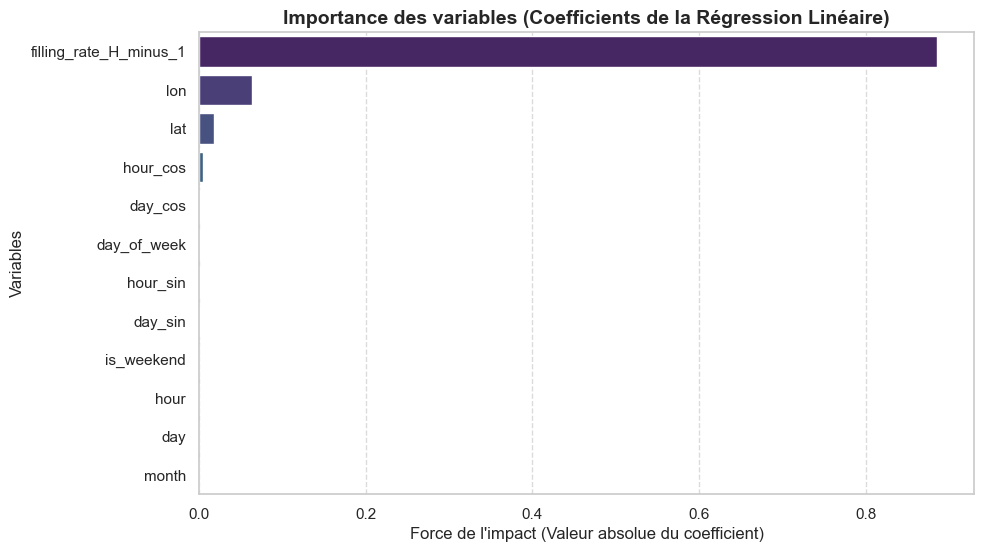

 Détail des impacts (coefficients réels) :
              Variable   Coefficient
filling_rate_H_minus_1  8.861849e-01
                   lon -6.353977e-02
                   lat  1.727572e-02
              hour_cos  5.008442e-03
               day_cos  1.093991e-03
           day_of_week  8.611878e-04
              hour_sin  8.211082e-04
               day_sin  8.076014e-04
            is_weekend  2.312530e-04
                  hour  9.748107e-05
                   day -4.844143e-06
                 month  2.775558e-17


In [52]:

# 1. On récupère les coefficients et on les lie aux noms des colonnes
importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': modele_lr.coef_
})

# On ajoute une colonne pour la valeur absolue 
importances['Abs_Coefficient'] = importances['Coefficient'].abs()

# 2. On trie par importance absolue
importances = importances.sort_values(by='Abs_Coefficient', ascending=False)

# 3. Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importances, 
    x='Abs_Coefficient', 
    y='Variable', 
    palette='viridis'
)

plt.title('Importance des variables (Coefficients de la Régression Linéaire)', fontsize=14, fontweight='bold')
plt.xlabel('Force de l\'impact (Valeur absolue du coefficient)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# Petit bonus : on affiche les vrais coefficients (positifs ou négatifs) en texte
print(" Détail des impacts (coefficients réels) :")
print(importances[['Variable', 'Coefficient']].to_string(index=False))

Comme nous pouvons le voir sur le graphique ci-dessus, la colonne **filling_rate_H_minus_1** est, de très loin, le **feature le plus important** de notre modèle. Son influence est capitale par rapport aux autres variables (coordonnées GPS ou calendrier), ce qui confirme la forte inertie temporelle des stations Vélib'.

### Random Forest Regressor
Après avoir établi une solide **Baseline** avec la Régression Linéaire (R² ~0.76), nous passons à un algorithme plus sophistiqué : le **Random Forest Regressor**.

**Pourquoi ce choix ?**
La régression linéaire part du principe que les relations sont des lignes droites. Cependant, le comportement des cyclistes est souvent plus complexe. Le **Random Forest** est capable de capturer des relations **non-linéaires** et des interactions entre les variables (par exemple : l'effet de l'heure est différent si nous sommes un lundi ou un dimanche).

**Comment ça marche ?**
Il s'agit d'un modèle de "Forêt Aléatoire" qui combine les prédictions de plusieurs dizaines d'**arbres de décision**. En faisant la moyenne de ces arbres, le modèle devient beaucoup plus robuste et moins sensible aux valeurs aberrantes que la régression classique.

In [53]:
from sklearn.ensemble import RandomForestRegressor

In [54]:
modele_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entraînement
print(" Entraînement du Random Forest en cours...")
modele_rf.fit(X_train, y_train)

# 3. Prédiction sur le Test set
predictions_rf = modele_rf.predict(X_test)

# 4. Évaluation des performances
mae_rf = mean_absolute_error(y_test, predictions_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))
r2_rf = r2_score(y_test, predictions_rf)

print("✅ Entraînement terminé !")
print("-" * 50)
print(" Résultats du Random Forest :")
print(f"MAE  (Erreur Moyenne) : {mae_rf:.4f}")
print(f"RMSE (Erreur Max)     : {rmse_rf:.4f}")
print(f"R²   (Score global)   : {r2_rf:.4f}")

 Entraînement du Random Forest en cours...
✅ Entraînement terminé !
--------------------------------------------------
 Résultats du Random Forest :
MAE  (Erreur Moyenne) : 0.1001
RMSE (Erreur Max)     : 0.1392
R²   (Score global)   : 0.7726


In [61]:
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit,RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [57]:

# 1. Création de la Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 2. Définition de la grille de paramètres
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10]
}

# 3. Stratégie de validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=3)

# 4. Configuration du Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=2
)

# 5. Entraînement
print("⏳ Optimisation via Pipeline en cours...")
grid_search.fit(X_train, y_train)

# 6. Résultats
print(f"\n🏆 Meilleurs paramètres : {grid_search.best_params_}")

# Évaluation du meilleur modèle (automatiquement sélectionné par grid_search)
y_pred = grid_search.predict(X_test)

print("\n📊 Performance du modèle optimisé :")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

⏳ Optimisation via Pipeline en cours...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=100; total time=   4.6s
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=100; total time=   8.5s
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=100; total time=  13.7s
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=200; total time=   7.7s
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=200; total time=  16.6s
[CV] END rf__max_depth=None, rf__min_samples_split=2, rf__n_estimators=200; total time=  25.7s
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=100; total time=   3.5s
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=100; total time=   7.5s
[CV] END rf__max_depth=None, rf__min_samples_split=5, rf__n_estimators=100; total time=  14.0s
[CV] END rf__max_depth=None, rf__min_samples

### Optimisation et Industrialisation : La Pipeline

Pour affiner les performances du **Random Forest**, nous avons mis en place une structure de code professionnelle appelée **Pipeline**.

**Pourquoi utiliser une Pipeline ?**
1. **Évite le Data Leakage :** La pipeline s'assure que la standardisation des données (StandardScaler) est calculée uniquement sur le jeu d'entraînement à chaque étape de la Cross-Validation. Cela garantit que le futur ne "fuit" jamais dans le passé.
2. **Industrialisation :** Elle regroupe le prétraitement et le modèle dans un seul objet. Pour prédire de nouvelles données, il suffit d'appeler `pipeline.predict()`, et toutes les étapes de calcul sont rejouées automatiquement.
3. **Fine-Tuning :** Couplée à un `GridSearchCV` et un `TimeSeriesSplit`, elle nous a permis de tester 18 combinaisons de paramètres pour identifier le modèle le plus performant.

### Le "Boss Final" : LightGBM (Light Gradient Boosting Machine)

Après avoir exploré la forêt aléatoire, nous passons à une technique encore plus puissante : le **Gradient Boosting** avec **LightGBM**.

**Quelle est la différence avec le Random Forest ?**
Alors que le Random Forest construit des arbres indépendants en parallèle, le Boosting les construit de manière **séquentielle**. Chaque nouvel arbre est conçu spécifiquement pour corriger les erreurs commises par les arbres précédents. 



**Pourquoi LightGBM ?**
* **Rapidité :** Il est optimisé pour être extrêmement rapide, même sur de gros jeux de données.
* **Précision :** Sa méthode de croissance des arbres "Leaf-wise" (par feuille plutôt que par niveau) lui permet souvent d'atteindre une précision supérieure aux autres algorithmes.

In [59]:
from lightgbm import LGBMRegressor

In [60]:
lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMRegressor(
        n_estimators=500,           # On met un peu plus d'arbres
        learning_rate=0.05,         # Pas à pas pour ne pas rater le minimum
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Entraînement
print(" Entraînement de LightGBM en cours...")
lgbm_pipeline.fit(X_train, y_train)

# 3. Prédictions
y_pred_lgbm = lgbm_pipeline.predict(X_test)

# 4. Évaluation
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("\n Résultats du modèle LightGBM :")
print(f"MAE  (Erreur Moyenne) : {mae_lgbm:.4f}")
print(f"RMSE (Erreur Max)     : {rmse_lgbm:.4f}")
print(f"R²   (Score global)   : {r2_lgbm:.4f}")

 Entraînement de LightGBM en cours...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 165893, number of used features: 11
[LightGBM] [Info] Start training from score 0.398660


c:\Users\maysttro\Desktop\Data Science\Projects\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 Résultats du modèle LightGBM :
MAE  (Erreur Moyenne) : 0.0912
RMSE (Erreur Max)     : 0.1273
R²   (Score global)   : 0.8099


### Fine-Tuning de LightGBM via RandomizedSearchCV

Pour tirer le maximum de **LightGBM**, nous allons explorer ses hyperparamètres de manière intelligente en utilisant un **RandomizedSearchCV**. 

**Pourquoi RandomizedSearchCV plutôt que GridSearchCV ?**
Le `RandomizedSearchCV` ne teste pas toutes les combinaisons possibles, ce qui serait extrêmement coûteux en temps de calcul. À la place, il tire au sort un nombre défini d'itérations (`n_iter`). Statistiquement, cette méthode permet de trouver des paramètres quasi-optimaux beaucoup plus rapidement en couvrant mieux l'espace des solutions.

In [62]:
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform

In [63]:
# 1. On définit la Pipeline
lgbm_pipeline_opti = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1))
])

# 2. On définit la plage des paramètres (distributions)
param_dist = {
    'lgbm__n_estimators': [100, 500, 1000],
    'lgbm__num_leaves': sp_randint(20, 150),       # Nombre de feuilles (complexité)
    'lgbm__learning_rate': sp_uniform(0.01, 0.2), # Vitesse d'apprentissage
    'lgbm__min_child_samples': sp_randint(10, 50), # Pour éviter l'overfitting
    'lgbm__max_depth': [-1, 10, 20, 30]           # Profondeur max (-1 = pas de limite)
}

# 3. Cross-Validation Temporelle
tscv = TimeSeriesSplit(n_splits=3)

# 4. Configuration du RandomizedSearch
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipeline_opti,
    param_distributions=param_dist,
    n_iter=20,                           # On teste 20 combinaisons au hasard
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 5. Entraînement
print(" Recherche aléatoire des meilleurs paramètres LightGBM...")
random_search_lgbm.fit(X_train, y_train)

# 6. Meilleurs paramètres et Scores
print(f"\n Meilleurs paramètres trouvés : {random_search_lgbm.best_params_}")

y_pred_lgbm_final = random_search_lgbm.predict(X_test)

print("\n Score de LightGBM Optimisé :")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lgbm_final):.4f}")
print(f"R²  : {r2_score(y_test, y_pred_lgbm_final):.4f}")

 Recherche aléatoire des meilleurs paramètres LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 165893, number of used features: 11
[LightGBM] [Info] Start training from score 0.398660

 Meilleurs paramètres trouvés : {'lgbm__learning_rate': np.float64(0.011413261043943482), 'lgbm__max_depth': -1, 'lgbm__min_child_samples': 36, 'lgbm__n_estimators': 1000, 'lgbm__num_leaves': 34}


c:\Users\maysttro\Desktop\Data Science\Projects\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 Score de LightGBM Optimisé :
MAE : 0.0904
R²  : 0.8083


C:\Users\maysttro\AppData\Local\Temp\ipykernel_14856\1333546635.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Modèle', y='MAE', palette='viridis')


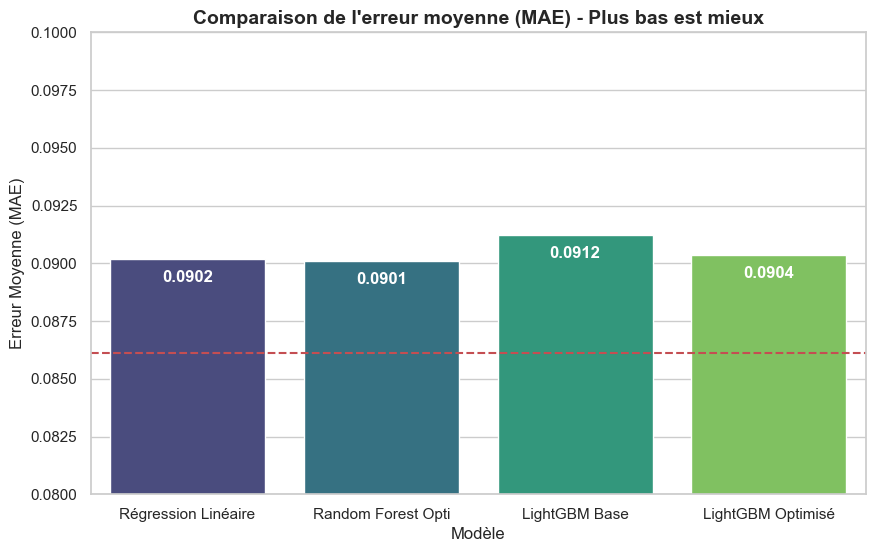

In [68]:

final_results = {
    'Modèle': ['Régression Linéaire', 'Random Forest Opti', 'LightGBM Base', 'LightGBM Optimisé'],
    'MAE': [0.0902, 0.0901, mean_absolute_error(y_test, y_pred_lgbm), mean_absolute_error(y_test, y_pred_lgbm_final)]
}

df_final = pd.DataFrame(final_results)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_final, x='Modèle', y='MAE', palette='viridis')
plt.axhline(y=0.0861, color='r', linestyle='--')
plt.title('Comparaison de l\'erreur moyenne (MAE) - Plus bas est mieux', fontsize=14, fontweight='bold')
plt.ylabel('Erreur Moyenne (MAE)')
plt.ylim(0.08, 0.10)

for i, val in enumerate(df_final['MAE']):
    plt.text(i, val - 0.001, f'{val:.4f}', ha='center', color='white', fontweight='bold')

plt.show()

In [71]:
# On enregistre la pipeline complète (scaler + modèle)
joblib.dump(random_search_lgbm.best_estimator_, 'velib_model_lgbm_final.pkl')

print(" Modèle sauvegardé sous le nom 'velib_model_lgbm_final.pkl'")

 Modèle sauvegardé sous le nom 'velib_model_lgbm_final.pkl'
